# Exploratory Data Analysis

This notebook explores the cleaned Online Retail dataset to identify sales performance trends, product performance, and customer insights.

The analysis focuses on generating business insights from transaction data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(
    "../data/processed/online_retail_clean.csv",
    dtype={'InvoiceNo': 'str'}
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
df.shape

(524878, 9)

# 1. Sales Performance Analysis

This section analyzes the overall sales performance using key business metrics.

In [4]:
total_revenue = df['Revenue'].sum()

total_revenue

np.float64(10642110.804000001)

In [5]:
total_transactions = df['InvoiceNo'].nunique()

total_transactions

19960

In [6]:
average_transaction = (
    total_revenue / total_transactions
)

average_transaction

np.float64(533.171883967936)

## Sales Performance Summary

The cleaned dataset contains 19,960 unique transactions.

The total revenue generated is £10.64 million, with an average transaction value of approximately £533.17.

These metrics provide an overview of the company's overall sales performance.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524878 non-null  str    
 1   StockCode    524878 non-null  str    
 2   Description  524878 non-null  str    
 3   Quantity     524878 non-null  int64  
 4   InvoiceDate  524878 non-null  str    
 5   UnitPrice    524878 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      524878 non-null  str    
 8   Revenue      524878 non-null  float64
dtypes: float64(3), int64(1), str(5)
memory usage: 36.0 MB


## Convert InvoiceDate to Datetime

InvoiceDate is converted into datetime format to support time-based analysis.

In [8]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate']
)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  str           
 1   StockCode    524878 non-null  str           
 2   Description  524878 non-null  str           
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[us]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  str           
 8   Revenue      524878 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 36.0 MB


In [10]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [11]:
df[['InvoiceDate','Month']].head()

,InvoiceDate,Month
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [12]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Monthly Revenue Trend

This analysis shows the monthly revenue performance to identify sales patterns and trends over time.

In [13]:
monthly_sales = (
    df.groupby('Month')['Revenue']
    .sum()
    .reset_index()
)

monthly_sales

,Month,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


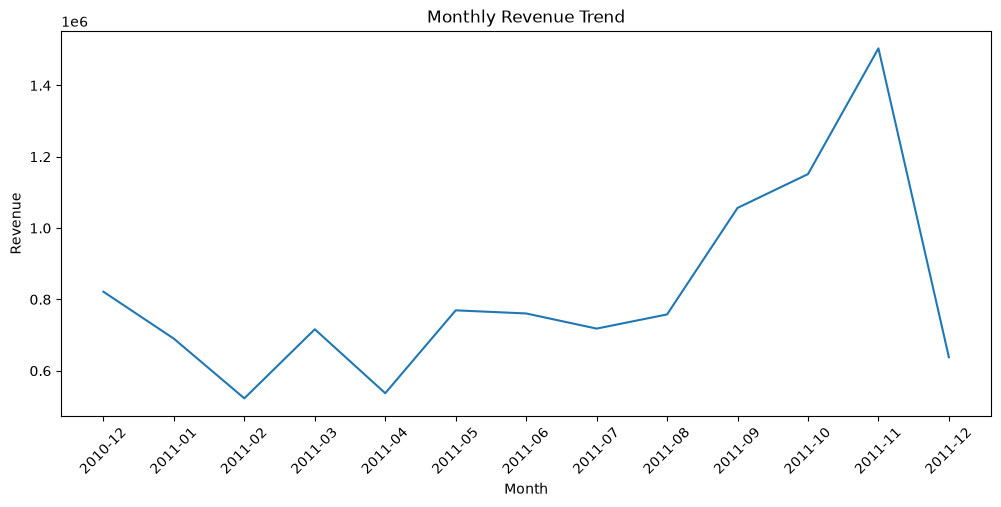

In [14]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales['Month'].astype(str),
    monthly_sales['Revenue']
)

plt.xticks(rotation=45)

plt.title(
    "Monthly Revenue Trend"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Revenue"
)

plt.show()

## Monthly Revenue Insights

The monthly revenue analysis shows that sales performance fluctuated throughout the period.

Revenue increased significantly during September to November 2011, with November becoming the highest revenue month.

The decline in December may be influenced by the shorter observation period and incomplete monthly transaction coverage.

# Product Performance Analysis

This section analyzes product performance based on quantity sold and revenue contribution.

In [16]:
top_products_quantity = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_quantity

,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3,JUMBO BAG RED RETROSPOT,48371
4,WHITE HANGING HEART T-LIGHT HOLDER,37872
5,POPCORN HOLDER,36749
6,PACK OF 72 RETROSPOT CAKE CASES,36396
7,ASSORTED COLOUR BIRD ORNAMENT,36362
8,RABBIT NIGHT LIGHT,30739
9,MINI PAINT SET VINTAGE,26633


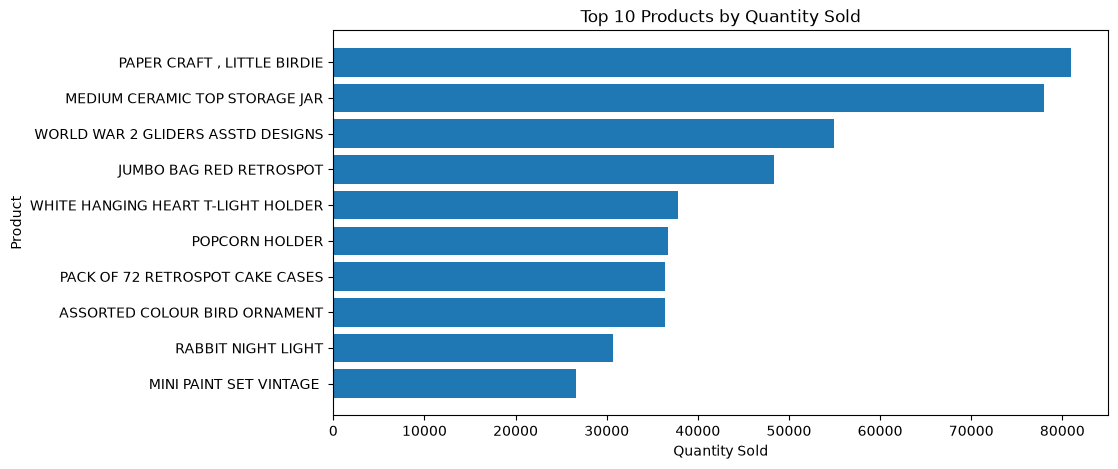

In [17]:
plt.figure(figsize=(10,5))

plt.barh(
    top_products_quantity['Description'],
    top_products_quantity['Quantity']
)

plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.title(
    "Top 10 Products by Quantity Sold"
)

plt.gca().invert_yaxis()

plt.show()

## Top Products by Quantity Sold

The analysis shows that PAPER CRAFT, LITTLE BIRDIE has the highest sales volume based on quantity sold.

Other high-volume products include MEDIUM CERAMIC TOP STORAGE JAR and WORLD WAR 2 GLIDERS ASSTD DESIGNS.

These products represent items with strong customer demand based on the number of units purchased.

## Top Products by Revenue

This analysis identifies products that generate the highest revenue contribution.

In [18]:
top_products_revenue = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_revenue

,Description,Revenue
0,DOTCOM POSTAGE,206248.77
1,REGENCY CAKESTAND 3 TIER,174156.54
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
4,PARTY BUNTING,99445.23
5,JUMBO BAG RED RETROSPOT,94159.81
6,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
7,POSTAGE,78101.88
8,Manual,77752.82
9,RABBIT NIGHT LIGHT,66870.03


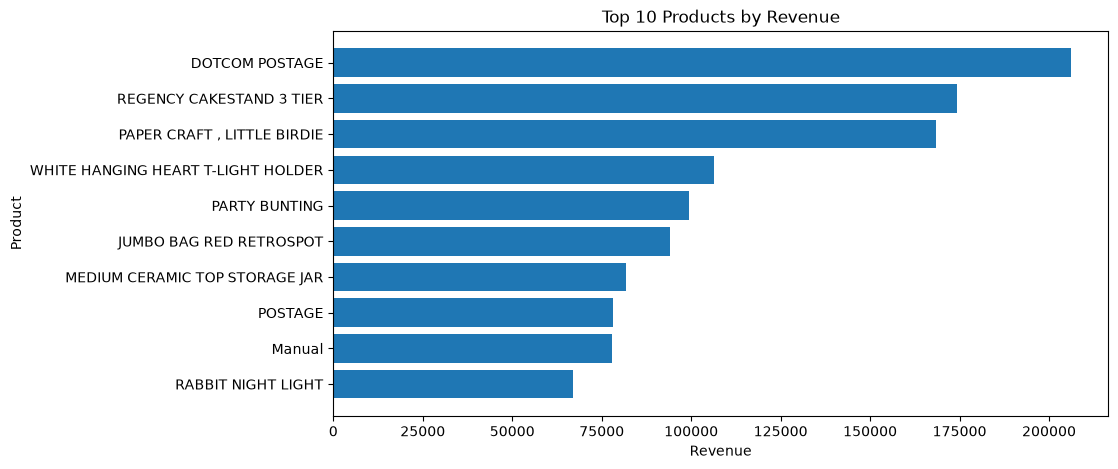

In [19]:
plt.figure(figsize=(10,5))

plt.barh(
    top_products_revenue['Description'],
    top_products_revenue['Revenue']
)

plt.xlabel("Revenue")
plt.ylabel("Product")

plt.title(
    "Top 10 Products by Revenue"
)

plt.gca().invert_yaxis()

plt.show()

## Top Products by Revenue Insights

The revenue analysis shows that DOTCOM POSTAGE generated the highest revenue contribution.

Several products appear consistently in both quantity-based and revenue-based rankings, such as PAPER CRAFT, LITTLE BIRDIE, indicating strong customer demand and significant business contribution.

Revenue-based analysis provides a different perspective from quantity analysis because high sales volume does not always represent the highest financial contribution.

# Country Sales Analysis

This section analyzes sales contribution across different countries.

In [20]:
country_sales = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

country_sales

,Country,Revenue
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


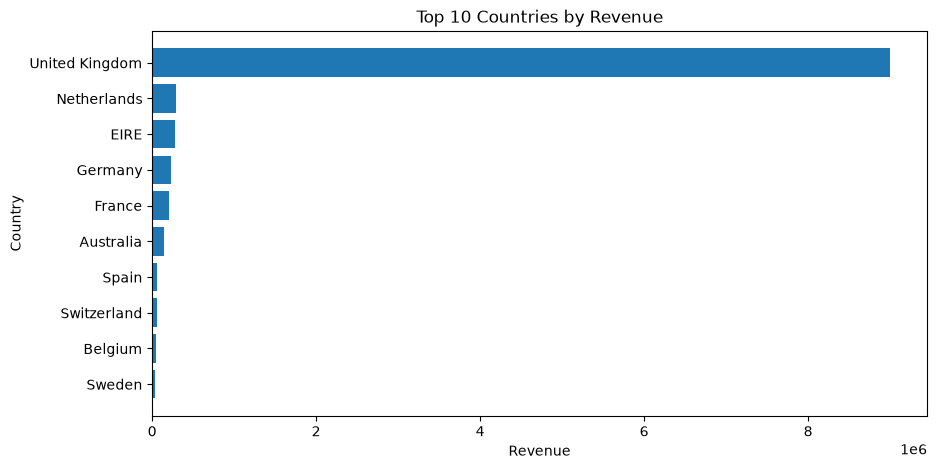

In [21]:
plt.figure(figsize=(10,5))

plt.barh(
    country_sales['Country'],
    country_sales['Revenue']
)

plt.xlabel("Revenue")
plt.ylabel("Country")

plt.title(
    "Top 10 Countries by Revenue"
)

plt.gca().invert_yaxis()

plt.show()

## Country Sales Insights

The country-level analysis shows that the United Kingdom contributes the largest portion of revenue compared to other countries.

Although the UK dominates sales performance, several European countries such as Netherlands, Germany, and France also contribute to international revenue.

This indicates that the business has a strong domestic market presence while maintaining international customer demand.

# Customer Analysis

This section identifies customers with the highest revenue contribution.

In [22]:
df['CustomerID'].isnull().sum()

np.int64(132186)

In [23]:
customer_df = df.dropna(
    subset=['CustomerID']
)

In [24]:
top_customers = (
    customer_df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_customers

,CustomerID,Revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124914.53
6,14156.0,117210.08
7,17511.0,91062.38
8,16029.0,80850.84
9,12346.0,77183.60


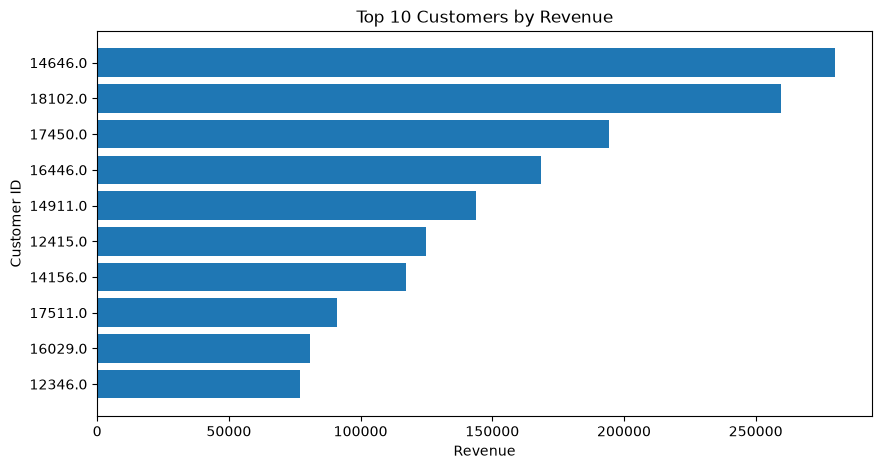

In [25]:
plt.figure(figsize=(10,5))

plt.barh(
    top_customers['CustomerID'].astype(str),
    top_customers['Revenue']
)

plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.title(
    "Top 10 Customers by Revenue"
)

plt.gca().invert_yaxis()

plt.show()

## Customer Revenue Insights

The customer analysis shows that a small number of customers contribute significantly to total revenue.

Customer ID 14646 generated the highest revenue contribution, followed by several other high-value customers.

These customers can be considered important contributors to business performance and may represent potential targets for customer retention strategies.

# Business Insights Summary

## 1. Overall Sales Performance

The analysis shows that the business generated total revenue of approximately £10.64 million from 19,960 unique transactions.

The average transaction value was approximately £533.17, indicating that each transaction contributed significant sales value.

## 2. Monthly Revenue Trend

Monthly analysis shows that sales performance fluctuated throughout the year.

Revenue increased significantly during the last quarter of 2011, with November 2011 becoming the highest revenue month.

This indicates stronger sales performance towards the end of the year.

## 3. Product Performance

Product analysis shows differences between products with high sales volume and products with high revenue contribution.

PAPER CRAFT, LITTLE BIRDIE appears as one of the strongest performing products based on both quantity sold and revenue contribution.

This indicates strong customer demand for this product.

## 4. Geographic Sales Performance

Country analysis shows that the United Kingdom contributes the largest share of revenue compared to other countries.

Several European countries such as Netherlands, Germany, and France also contribute to international sales.

## 5. Customer Contribution

Customer analysis indicates that a small group of customers contributes a significant portion of revenue.

Customer ID 14646 generated the highest revenue contribution among identified customers.

These high-value customers represent important contributors to business performance.